# Занятие 01. Первичный анализ внешнего набора данных: ElectricMotorTemperature, Zenodo TSML Archive

## Теоретический блок

Набор данных рассматривается как инженерная таблица наблюдений. Наблюдение -
одна строка, соответствующая измеренному или расчетному состоянию объекта.
Признак (feature) - входная величина анализа. Диагностический столбец -
величина, полезная для объяснения источника данных, но потенциально опасная
как вход модели из-за утечки данных (data leakage).

Источник: https://zenodo.org/records/11235562.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_motor_temperature_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_motor_temperature_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_motor_temperature_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
DATASET_ID = "zenodo_motor_temperature"
DATASET_TITLE = "ElectricMotorTemperature, Zenodo TSML Archive"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    return data.index[~test_mask], data.index[test_mask], test_groups


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_motor_temperature_features.csv
Размер feature-таблицы: (12000, 13)


,sample_id,profile_id,time_index,channel_00_mean,channel_01_mean,channel_02_mean,channel_03_mean,channel_04_mean,channel_05_mean,channel_00_trend,channel_01_trend,target_temperature_c,is_allowed
0,1,1000,0,-1.077220,1.367135,1.097118,-2.000468,25.905690,18.289637,0.012883,0.021129,54.556091,1
1,2,1000,1,127.949503,27.574080,-24.319673,-46.308822,28.158680,41.524931,5.868119,-28.250566,72.535668,1
2,3,1000,2,12.068943,0.870153,1.098589,-2.000007,22.730333,18.365001,0.016368,0.005058,27.399111,1
3,4,1000,3,126.008307,34.879808,-25.117721,-86.576199,27.708449,56.422220,-4.558056,10.908588,74.043505,1
4,5,1000,4,-0.396174,-0.748006,1.097415,-2.000649,24.450017,59.723624,0.029844,-0.074059,72.560170,1


In [2]:
metadata_text = METADATA_FILE.read_text(encoding="utf-8") if METADATA_FILE.exists() else "Метаданные не найдены."
print(metadata_text)


# ElectricMotorTemperature, Zenodo TSML Archive

- Идентификатор: `zenodo_motor_temperature`.
- Источник: https://zenodo.org/records/11235562.
- Лицензия и доступ: CC BY 4.0; прямая загрузка файлов формата .ts из Zenodo.
- Статус подготовки: `prepared`.
- Число строк в компактной учебной выборке: 12000.

Методическое назначение: расширенные блокноты занятий 1-3 с реальными
или открытыми инженерными данными. Feature-CSV используется для базовой
модели, diagnostics-CSV - для пояснения происхождения целевых переменных,
ограничений и возможной утечки данных.

Дополнительные замечания:
- Формат исходных файлов: multivariate .ts, то есть многомерные временные ряды.
- Архив содержит стандартизованные временные фрагменты длиной 60 отсчетов и целевую температуру.
- Целевая переменная регрессии: `target_temperature_c`.
- Целевая переменная классификации: `is_allowed`, производная от квантиля целевой температуры.
- Физические имена каналов в .ts-файлах не заданы, поэтому признаки названы нейтраль

In [3]:
dataset_passport = pd.DataFrame(
    {
        "field": [
            "dataset_id",
            "title",
            "source_status",
            "rows_features",
            "columns_features",
            "group_column",
            "time_column",
            "regression_target",
            "classification_target",
        ],
        "value": [
            DATASET_ID,
            DATASET_TITLE,
            source_status,
            features_df.shape[0],
            features_df.shape[1],
            GROUP_COLUMN,
            TIME_COLUMN,
            "target_temperature_c",
            "is_allowed",
        ],
    }
)
dataset_passport


,field,value
0,dataset_id,zenodo_motor_temperature
1,title,"ElectricMotorTemperature, Zenodo TSML Archive"
2,source_status,external
3,rows_features,12000
4,columns_features,13
5,group_column,profile_id
6,time_column,time_index
7,regression_target,target_temperature_c
8,classification_target,is_allowed


In [4]:
analysis_columns = ['channel_00_mean', 'channel_01_mean', 'channel_02_mean', 'channel_03_mean', 'channel_04_mean', 'channel_05_mean', 'target_temperature_c']
features_df[analysis_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
channel_00_mean,12000.0,54.521554,42.634663,-23.368484,13.630266,50.013621,88.651306,132.026640
channel_01_mean,12000.0,-25.289016,61.055529,-131.391749,-75.757284,-7.607500,1.461710,131.377380
channel_02_mean,12000.0,36.989680,90.061892,-282.286788,1.096842,15.774166,98.030710,301.706526
channel_03_mean,12000.0,-68.731989,63.110252,-273.812592,-115.165135,-53.884276,-3.392365,0.000778
channel_04_mean,12000.0,24.579522,1.921633,18.505460,23.196298,24.789330,26.209105,30.011135
channel_05_mean,12000.0,36.393515,21.927014,14.266478,18.709111,26.976872,49.882600,93.584485
target_temperature_c,12000.0,58.870588,19.061865,21.230591,43.373047,60.580965,72.470680,113.606628


In [5]:
missing_table = (
    features_df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_share=lambda x: x["missing_count"] / len(features_df))
)
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_share


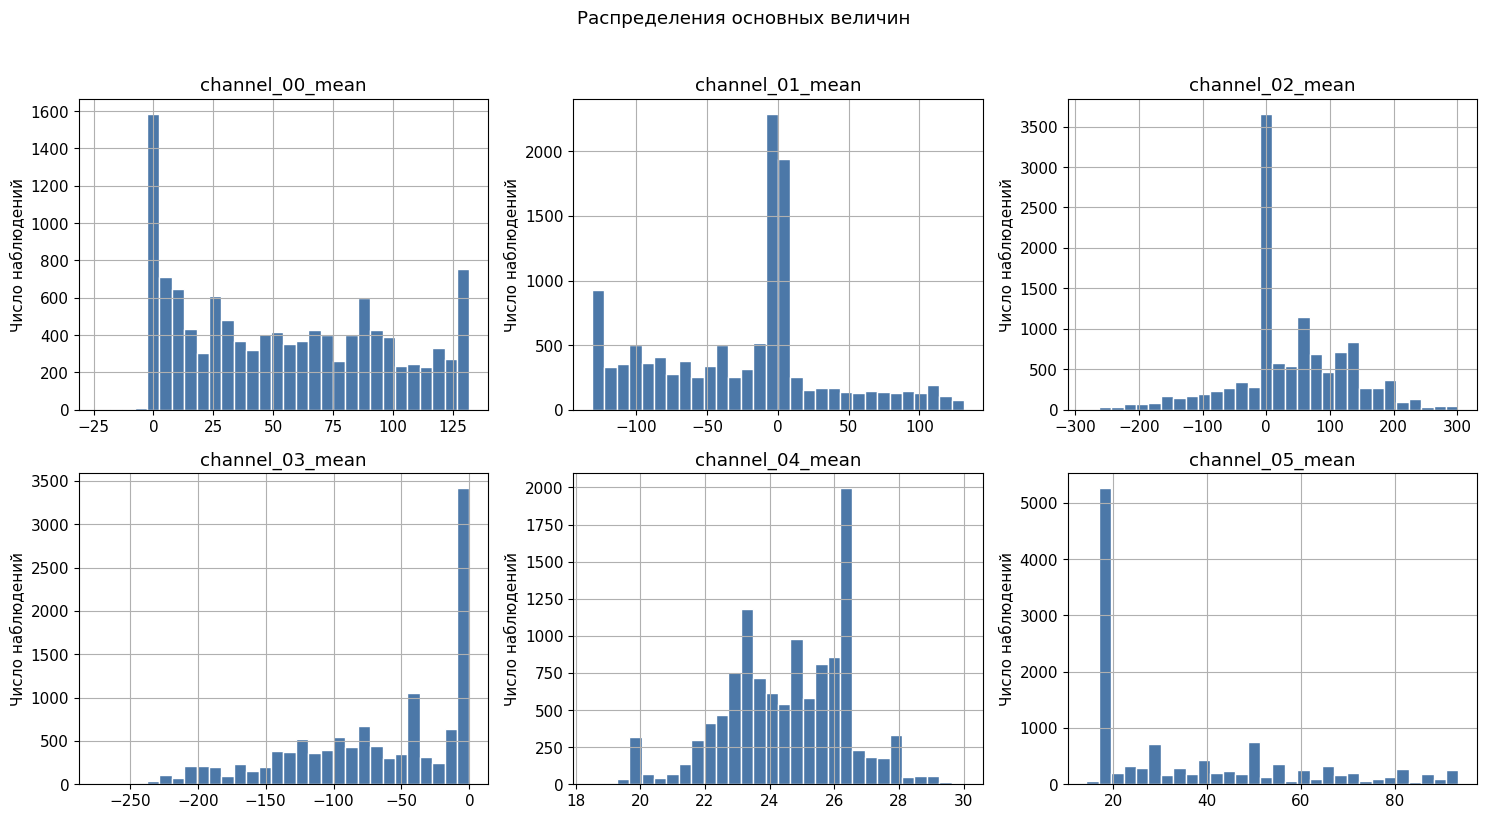

In [6]:
numeric_columns = features_df.select_dtypes(include=[np.number]).columns.tolist()
shown_columns = [column for column in analysis_columns if column in numeric_columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, column in zip(axes, shown_columns[:6]):
    ax.hist(features_df[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Число наблюдений")
for ax in axes[len(shown_columns[:6]):]:
    ax.set_axis_off()
plt.suptitle("Распределения основных величин", y=1.02)
plt.tight_layout()
plt.show()


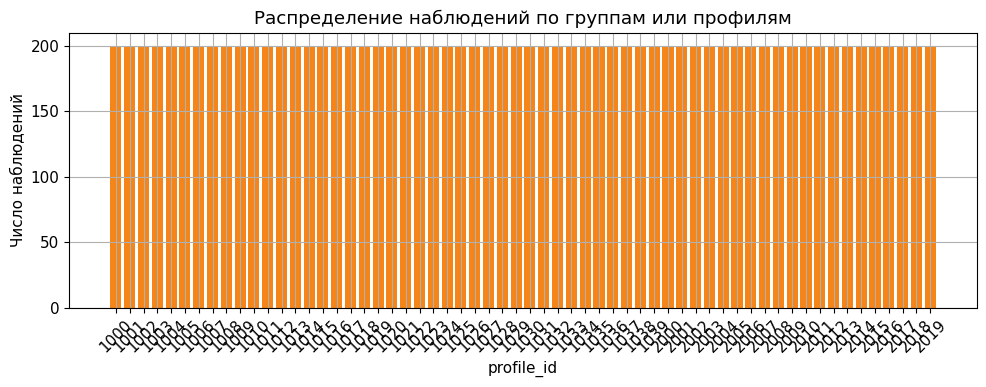

profile_id
1000    200
1001    200
1002    200
1003    200
1004    200
1005    200
1006    200
1007    200
1008    200
1009    200
1010    200
1011    200
1012    200
1013    200
1014    200
1015    200
1016    200
1017    200
1018    200
1019    200
Name: count, dtype: int64

In [7]:
if GROUP_COLUMN in features_df.columns:
    group_counts = features_df[GROUP_COLUMN].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(group_counts.index.astype(str), group_counts.values, color="#f58518")
    ax.set_xlabel(GROUP_COLUMN)
    ax.set_ylabel("Число наблюдений")
    ax.set_title("Распределение наблюдений по группам или профилям")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
group_counts.head(20) if GROUP_COLUMN in features_df.columns else "Групповой столбец отсутствует"


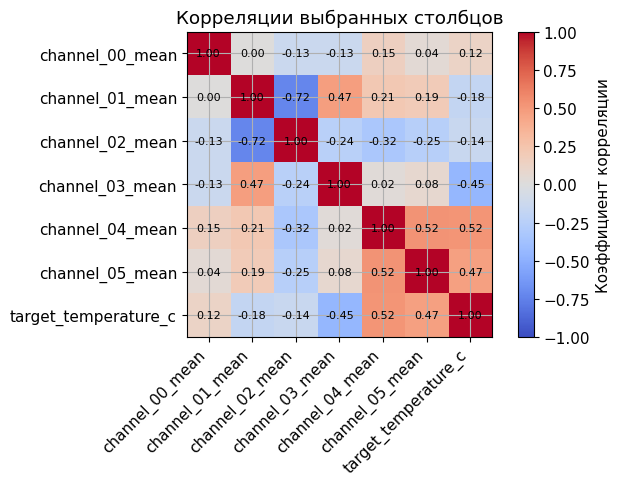

In [8]:
plot_correlation_heatmap(
    features_df,
    [column for column in analysis_columns if column in features_df.columns],
    "Корреляции выбранных столбцов",
)


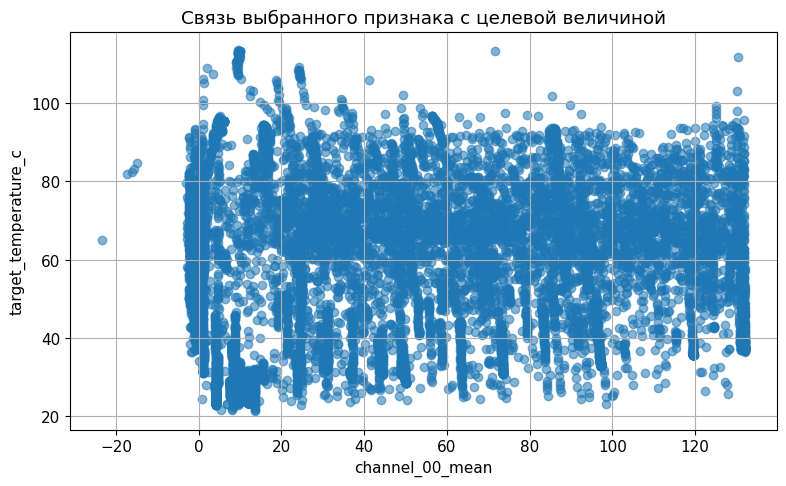

In [9]:
x_column = analysis_columns[0]
y_column = "target_temperature_c"
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(features_df[x_column], features_df[y_column], alpha=0.55)
ax.set_xlabel(x_column)
ax.set_ylabel(y_column)
ax.set_title("Связь выбранного признака с целевой величиной")
plt.tight_layout()
plt.show()


## Задание

1. Опишите источник данных, объект наблюдения и единицу наблюдения.
2. Разделите столбцы на измеряемые, расчетные, служебные и диагностические.
3. Постройте не менее двух графиков и одну таблицу описательной статистики.
4. Объясните, какие столбцы могут привести к утечке данных в занятиях 02-03.
5. Сформулируйте индивидуальный инженерный вывод.
